In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [2]:
train_path = r"C:\Users\harsh\Downloads\Traffic_Light\Traffic_Light\train"
test_path = r"C:\Users\harsh\Downloads\Traffic_Light\Traffic_Light\test"

Image Processing

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    shear_range=0.2
)

test_datagen = ImageDataGenerator(rescale=1/255)

Load Dataset

In [4]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 300 images belonging to 3 classes.


Found 60 images belonging to 3 classes.
{'Green': 0, 'Red': 1, 'Yellow': 2}


In [5]:
%pip install pillow

Note: you may need to restart the kernel to use updated packages.


Display One Sample Image

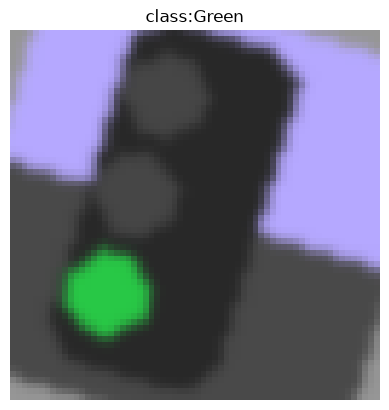

In [6]:
#Get One batch of Images

#Display the first image
# Get one batch of images
import numpy as np


images, labels = next(train_generator)

# Display the first image
plt.imshow(images[0])
plt.title("class:" + list(train_generator.class_indices.keys())[np.argmax(labels[0])])
plt.axis("off")
plt.show()


In [7]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\harsh\OneDrive\Desktop\AICONCEPT\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,587 (2.61 MB)

 Trainable params: 683,587 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Compile model

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [9]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.7033 - loss: 0.7315 - val_accuracy: 1.0000 - val_loss: 0.0559
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9933 - loss: 0.0465 - val_accuracy: 1.0000 - val_loss: 2.2321e-04
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 364ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 2.5828e-06
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 591ms/step - accuracy: 1.0000 - loss: 1.1676e-04 - val_accuracy: 1.0000 - val_loss: 3.5763e-08
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 507ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 2.8014e-07
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 521ms/step - accuracy: 1.0000 - loss: 1.2369e-04 - val_accuracy: 1.0000 - val_loss: 4.2080e-06
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 1.0000 - loss: 3.2023e-04 - val_accuracy: 1.0000 - val_loss: 1.7742e-06
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 1.000

Evaluate Model

In [10]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 1.5895e-08 
Test Accuracy: 1.0


plot Accuracy

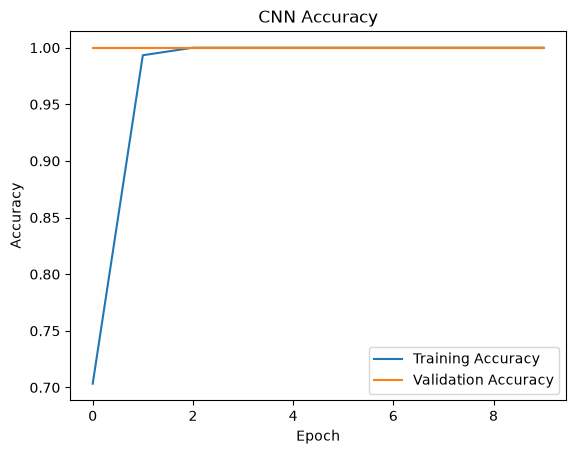

In [11]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()